In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

G = 9.81
KH_DEEP = np.pi
KH_SHALLOW = np.pi / 10


def solve_wavenumber(omega, depth):
    if depth <= 0:
        return np.nan

    def residual(wavenumber):
        return omega**2 - G * wavenumber * np.tanh(wavenumber * depth)

    lower = omega**2 / G
    upper = max(lower, omega / np.sqrt(G * depth))
    while residual(upper) > 0:
        upper *= 2
    return brentq(residual, lower, upper, xtol=1e-10)


def wave_properties(frequency, depth):
    depth = np.asarray(depth, dtype=float)
    omega = 2 * np.pi * frequency
    wavenumber = np.array([solve_wavenumber(omega, value) for value in depth])
    kh = wavenumber * depth
    wavelength = 2 * np.pi / wavenumber
    phase_speed = omega / wavenumber
    group_factor = 0.5 * (1 + 2 * kh / np.sinh(np.clip(2 * kh, 0, 700)))
    group_speed = group_factor * phase_speed
    deep_group_speed = G / (2 * omega)
    shoaling = np.sqrt(deep_group_speed / group_speed)
    return {
        "kh": kh,
        "wavelength": wavelength,
        "phase_speed": phase_speed,
        "group_speed": group_speed,
        "shoaling": shoaling,
    }


def transition_depth(frequency, kh):
    omega = 2 * np.pi * frequency
    return G * kh * np.tanh(kh) / omega**2


depth = np.linspace(8.0, 0.05, 500)
frequencies = np.array([0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50])
colors = plt.colormaps["viridis"](np.linspace(0.08, 0.92, len(frequencies)))

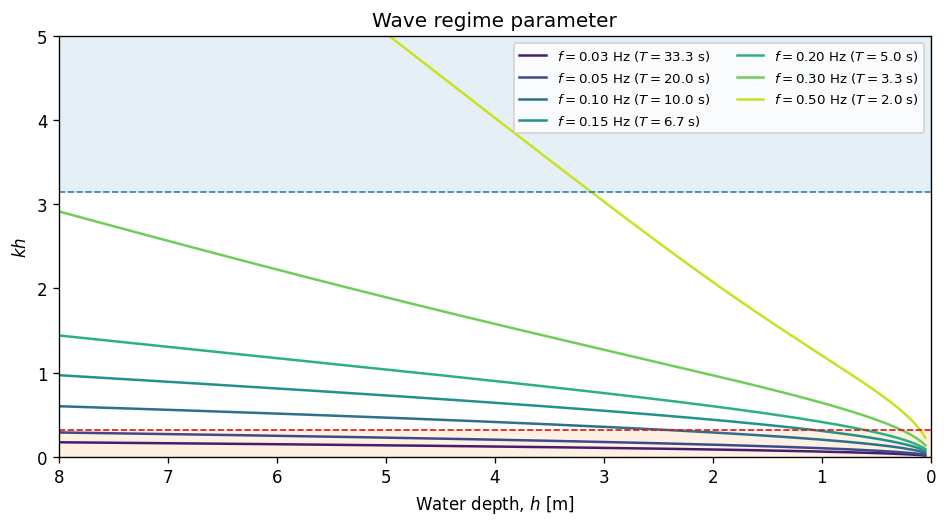

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.axhspan(0, KH_SHALLOW, color="#fdae61", alpha=0.18)
ax.axhspan(KH_DEEP, 5, color="#2b83ba", alpha=0.12)
for frequency, color in zip(frequencies, colors):
    values = wave_properties(frequency, depth)
    ax.plot(
        depth,
        values["kh"],
        color=color,
        label=rf"$f={frequency:.2f}$ Hz ($T={1 / frequency:.1f}$ s)",
    )

ax.axhline(KH_DEEP, color="#2b83ba", linestyle="--", linewidth=1)
ax.axhline(KH_SHALLOW, color="#d7191c", linestyle="--", linewidth=1)
ax.set(xlim=(8, 0), ylim=(0, 5), xlabel="Water depth, $h$ [m]", ylabel="$kh$")
ax.set_title("Wave regime parameter")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

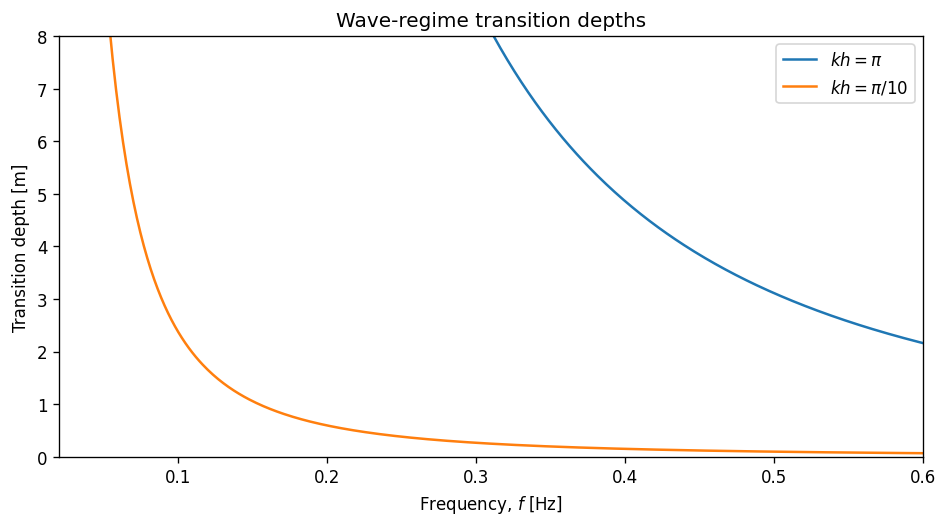

In [3]:
frequency_grid = np.linspace(0.02, 0.60, 500)
deep_transition = transition_depth(frequency_grid, KH_DEEP)
shallow_transition = transition_depth(frequency_grid, KH_SHALLOW)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(frequency_grid, deep_transition, label=r"$kh=\pi$")
ax.plot(frequency_grid, shallow_transition, label=r"$kh=\pi/10$")
ax.set(
    xlim=(0.02, 0.60),
    ylim=(0, 8),
    xlabel="Frequency, $f$ [Hz]",
    ylabel="Transition depth [m]",
)
ax.set_title("Wave-regime transition depths")
ax.legend()
fig.tight_layout()
plt.show()

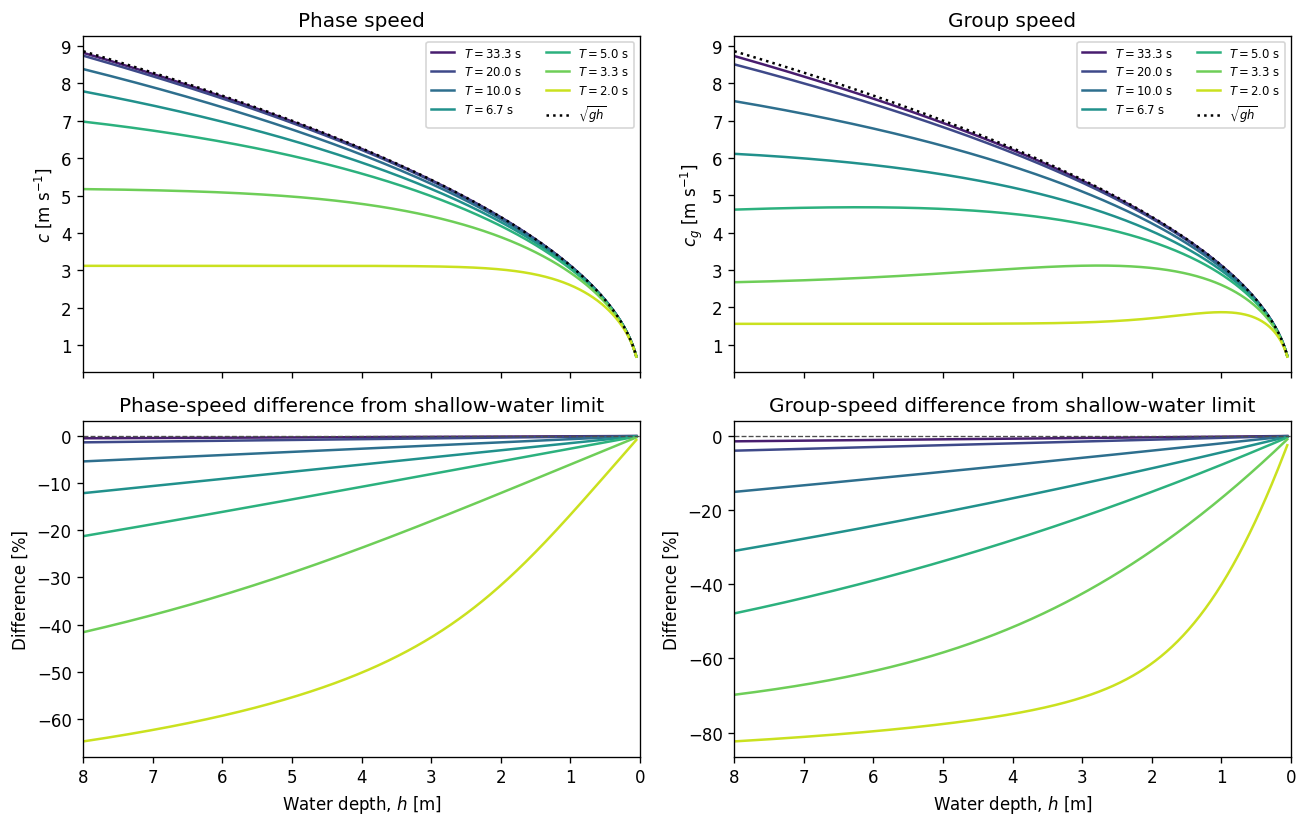

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
shallow_speed = np.sqrt(G * depth)

for frequency, color in zip(frequencies, colors):
    values = wave_properties(frequency, depth)
    label = rf"$T={1 / frequency:.1f}$ s"
    axes[0, 0].plot(depth, values["phase_speed"], color=color, label=label)
    axes[0, 1].plot(depth, values["group_speed"], color=color, label=label)
    axes[1, 0].plot(
        depth,
        100 * (values["phase_speed"] / shallow_speed - 1),
        color=color,
    )
    axes[1, 1].plot(
        depth,
        100 * (values["group_speed"] / shallow_speed - 1),
        color=color,
    )

axes[0, 0].plot(depth, shallow_speed, "k:", label=r"$\sqrt{gh}$")
axes[0, 1].plot(depth, shallow_speed, "k:", label=r"$\sqrt{gh}$")
axes[1, 0].axhline(0, color="0.3", linestyle="--", linewidth=0.8)
axes[1, 1].axhline(0, color="0.3", linestyle="--", linewidth=0.8)

titles = (
    "Phase speed",
    "Group speed",
    "Phase-speed difference from shallow-water limit",
    "Group-speed difference from shallow-water limit",
)
ylabels = ("$c$ [m s$^{-1}$]", "$c_g$ [m s$^{-1}$]", "Difference [%]", "Difference [%]")
for axis, title, ylabel in zip(axes.flat, titles, ylabels):
    axis.set(xlim=(8, 0), title=title, ylabel=ylabel)
for axis in axes[1]:
    axis.set_xlabel("Water depth, $h$ [m]")
for axis in axes[0]:
    axis.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

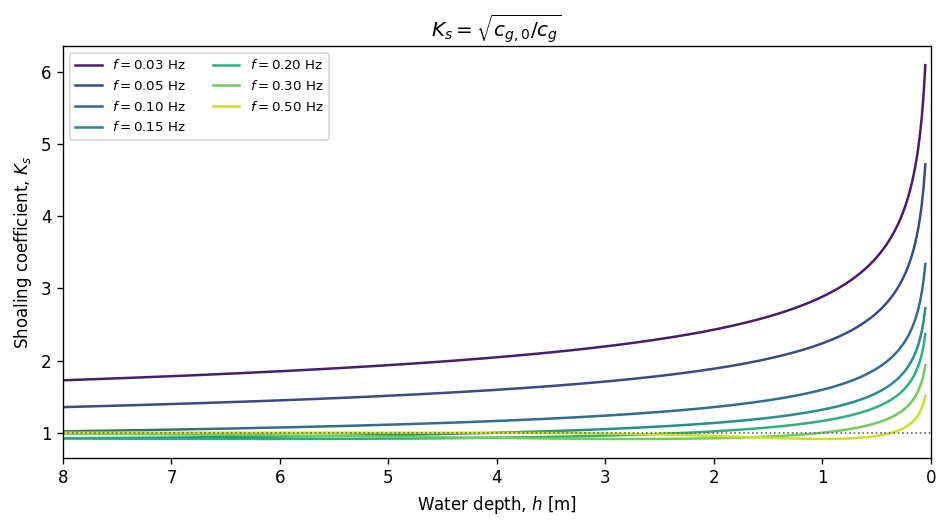

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for frequency, color in zip(frequencies, colors):
    values = wave_properties(frequency, depth)
    ax.plot(
        depth,
        values["shoaling"],
        color=color,
        label=rf"$f={frequency:.2f}$ Hz",
    )

ax.axhline(1, color="0.4", linestyle=":", linewidth=1)
ax.set(
    xlim=(8, 0),
    xlabel="Water depth, $h$ [m]",
    ylabel="Shoaling coefficient, $K_s$",
)
ax.set_title(r"$K_s=\sqrt{c_{g,0}/c_g}$")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

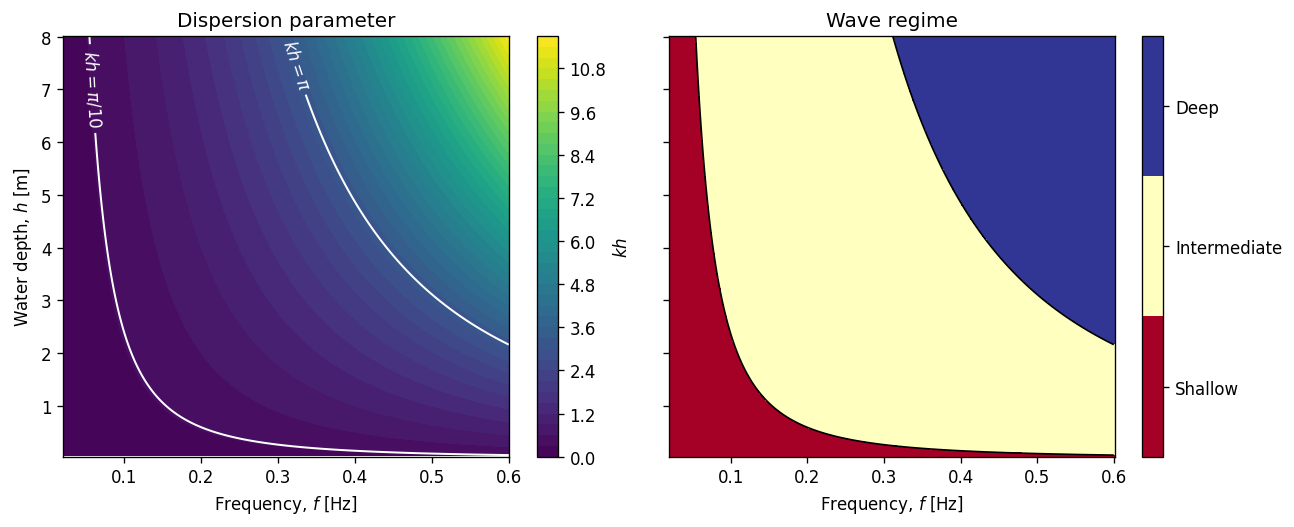

In [6]:
frequency_grid = np.linspace(0.02, 0.60, 300)
depth_grid = np.linspace(0.05, 8.0, 300)
frequency_mesh, depth_mesh = np.meshgrid(frequency_grid, depth_grid)
kh_grid = np.empty_like(frequency_mesh)

for row, depth_value in enumerate(depth_grid):
    for column, frequency_value in enumerate(frequency_grid):
        omega = 2 * np.pi * frequency_value
        kh_grid[row, column] = solve_wavenumber(omega, depth_value) * depth_value

regime = np.select(
    [kh_grid < KH_SHALLOW, kh_grid > KH_DEEP],
    [0, 2],
    default=1,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
kh_plot = axes[0].contourf(
    frequency_grid, depth_grid, kh_grid, levels=40, cmap="viridis"
)
boundaries = axes[0].contour(
    frequency_grid,
    depth_grid,
    kh_grid,
    levels=[KH_SHALLOW, KH_DEEP],
    colors="white",
    linewidths=1.2,
)
axes[0].clabel(
    boundaries,
    fmt={KH_SHALLOW: r"$kh=\pi/10$", KH_DEEP: r"$kh=\pi$"},
)
fig.colorbar(kh_plot, ax=axes[0], label="$kh$")

regime_plot = axes[1].pcolormesh(
    frequency_grid,
    depth_grid,
    regime,
    cmap=plt.colormaps["RdYlBu"].resampled(3),
    vmin=-0.5,
    vmax=2.5,
    shading="auto",
)
axes[1].contour(
    frequency_grid,
    depth_grid,
    kh_grid,
    levels=[KH_SHALLOW, KH_DEEP],
    colors="black",
    linewidths=1,
)
colorbar = fig.colorbar(regime_plot, ax=axes[1], ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Shallow", "Intermediate", "Deep"])

axes[0].set_title("Dispersion parameter")
axes[1].set_title("Wave regime")
for axis in axes:
    axis.set_xlabel("Frequency, $f$ [Hz]")
axes[0].set_ylabel("Water depth, $h$ [m]")
fig.tight_layout()
plt.show()

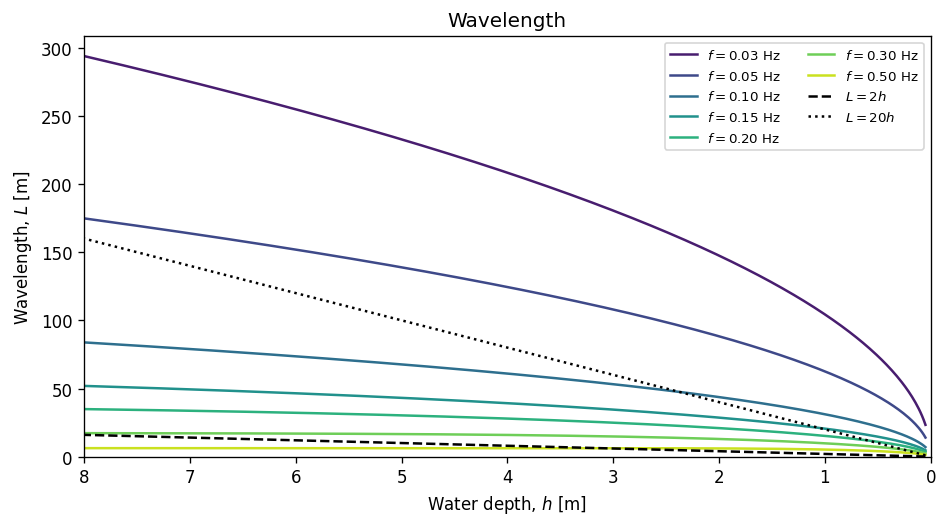

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for frequency, color in zip(frequencies, colors):
    values = wave_properties(frequency, depth)
    ax.plot(
        depth,
        values["wavelength"],
        color=color,
        label=rf"$f={frequency:.2f}$ Hz",
    )

reference_depth = np.linspace(0.05, 8, 300)
ax.plot(reference_depth, 2 * reference_depth, "k--", label=r"$L=2h$")
ax.plot(reference_depth, 20 * reference_depth, "k:", label=r"$L=20h$")
ax.set(
    xlim=(8, 0),
    ylim=(0, None),
    xlabel="Water depth, $h$ [m]",
    ylabel="Wavelength, $L$ [m]",
)
ax.set_title("Wavelength")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()